# Residual & Dilated U-Net model
Full pipeline for training:
```text
Batch of 2.5D samples
    ↓
U-Net (logits: [B, 1, H, W])
    ↓
Loss function
    ↓
Backpropagation (update model weights)
```
Inference
```text
CT sample [3, H, W]
    ↓
U-Net
    ↓
logits [1, H, W]
    ↓ sigmoid
probabilities [1, H, W]
    ↓ threshold
binary CAC mask [1, H, W]
```

## Use GPU for image processing (cuda)

In [ ]:
from pathlib import Path
import random, time
from dataclasses import dataclass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from tqdm.auto import tqdm
from scipy.ndimage import label

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", DEVICE)

PyTorch: 2.11.0+cu128
CUDA available: True
Device: cuda


## Inspect 1 .npy case
Create checkpoint paths

In [ ]:
def find_project_root(start: Path | None = None) -> Path:
    """Find the project folder that contains processed_data/images."""
    start = Path.cwd() if start is None else Path(start).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "Gated_release_final" / "processed_data" / "images").is_dir():
            return candidate
    raise FileNotFoundError(
        f"Could not find Gated_release_final/processed_data/images from {start}. "
        "Run this notebook from inside the project folder."
    )

PROJECT_ROOT = find_project_root()
DATA_ROOT = PROJECT_ROOT / "Gated_release_final" / "processed_data"
IMAGE_DIR = DATA_ROOT / "images"
MASK_DIR = DATA_ROOT / "masks"

# CHECKPOINT paths
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints_context"
CHECKPOINT_DIR.mkdir(exist_ok=True)

LATEST_CKPT_PATH = CHECKPOINT_DIR / "latest_checkpoint.pt"
BEST_CKPT_PATH = CHECKPOINT_DIR / "best_checkpoint.pt"
BEST_WEIGHTS_PATH = CHECKPOINT_DIR / "best_weights.pt"

case_id = "001"
image_path = IMAGE_DIR / f"{case_id}.npy"
mask_path = MASK_DIR / f"{case_id}.npy"

print("Project root:", PROJECT_ROOT)
print("Image path:", image_path)
print("Mask path:", mask_path)

images = np.load(image_path, mmap_mode="r")
masks = np.load(mask_path, mmap_mode="r")

print("Images shape:", images.shape)
print("Masks shape:", masks.shape)

print("Images dtype:", images.dtype)
print("Masks dtype:", masks.dtype)

print("Image min:", images.min())
print("Image max:", images.max())

print("Mask unique values:", np.unique(masks))
print("Total positive mask pixels:", masks.sum())

Project root: c:\Users\Quoc Thai\Downloads\AIO Conquer 3 - medical\cocacoronarycalciumandchestcts-2
Image path: c:\Users\Quoc Thai\Downloads\AIO Conquer 3 - medical\cocacoronarycalciumandchestcts-2\Gated_release_final\processed_data\images\001.npy
Mask path: c:\Users\Quoc Thai\Downloads\AIO Conquer 3 - medical\cocacoronarycalciumandchestcts-2\Gated_release_final\processed_data\masks\001.npy
Images shape: (57, 3, 512, 512)
Masks shape: (57, 1, 512, 512)
Images dtype: float32
Masks dtype: uint8
Image min: 0.0
Image max: 1.0
Mask unique values: [0 1]
Total positive mask pixels: 1115


In [87]:
col_counts = np.count_nonzero(masks > 0)
col_counts

np.int64(1115)

## Config & Helpers
Storing paths, specifications about data.
For strict reproducibility, use `deterministic`=True, `benchmark`=False.

In [ ]:
@dataclass
class CFG:
    DATA_ROOT: Path = DATA_ROOT
    INPUT_DIRNAME: Path = IMAGE_DIR
    MASK_DIRNAME: Path = MASK_DIR
    SPLIT_CSV: str = "case_splits_context.csv"

    BATCH_SIZE: int = 8
    NUM_WORKERS: int = 2
    PIN_MEMORY: bool = torch.cuda.is_available()

    SEED: int = 42
    EPOCHS: int = 10
    LR: float = 1e-4
    WEIGHT_DECAY: float = 1e-5
    MASK_THRESHOLD: float = 0.6

cfg = CFG()

INPUT_DIR = cfg.INPUT_DIRNAME
MASK_DIR = cfg.MASK_DIRNAME
SPLIT_PATH = cfg.DATA_ROOT / cfg.SPLIT_CSV

print("Input dir:", INPUT_DIR)
print("Mask dir:", MASK_DIR)
print("Split CSV:", SPLIT_PATH)

Input dir: c:\Users\Quoc Thai\Downloads\AIO Conquer 3 - medical\cocacoronarycalciumandchestcts-2\Gated_release_final\processed_data\images
Mask dir: c:\Users\Quoc Thai\Downloads\AIO Conquer 3 - medical\cocacoronarycalciumandchestcts-2\Gated_release_final\processed_data\masks
Split CSV: c:\Users\Quoc Thai\Downloads\AIO Conquer 3 - medical\cocacoronarycalciumandchestcts-2\Gated_release_final\processed_data\case_splits.csv


In [43]:
# Prioritize speed, not perfect reproducibility
# deterministic = False: allows faster CUDA algorithms, but results may vary slightly between runs
# benchmark = True: lets cuDNN test different conv algorithms and choose the fastest one.
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

seed_everything(cfg.SEED)
USE_AMP = DEVICE.type == "cuda"
# Speed up U-Net training
USE_CHANNELS_LAST = DEVICE.type == "cuda"

In [44]:
def fmt(v):
    return "None" if v is None else f"{v:.4f}"

## Load split table and verify case files

| case_id | split | % |
|---|---|---|
| case_001 | train | 70 |
| case_002 | val | 15 |
| case_003 | test | 15 |

convert `case_id` to string form, convert column to lowercase, remove spaces at start/end.

In [45]:
assert SPLIT_PATH.exists(), f"Missing split CSV: {SPLIT_PATH}"

splits_df = pd.read_csv(SPLIT_PATH)
required_cols = {"case_id", "split"}
assert required_cols.issubset(splits_df.columns), f"Missing columns: {required_cols - set(splits_df.columns)}"

splits_df["case_id"] = splits_df["case_id"].astype(str)
splits_df["split"] = splits_df["split"].str.lower().str.strip()

print(splits_df["split"].value_counts())
splits_df.head()


split
train    314
test      68
val       67
Name: count, dtype: int64


,case_id,split
0,3,test
1,13,test
2,22,test
3,28,test
4,36,test


In [46]:
def input_path_for(case_id: str) -> Path:
    return INPUT_DIR / f"{case_id}.npy"

def mask_path_for(case_id: str) -> Path:
    return MASK_DIR / f"{case_id}.npy"

manifest = []
for _, row in splits_df.iterrows():
    case_id = f"{int(row['case_id']):03d}"
    input_path = input_path_for(case_id)
    mask_path = mask_path_for(case_id)

    manifest.append({
        "case_id": case_id,
        "split": row["split"],
        "input_path": str(input_path),
        "mask_path": str(mask_path),
        "input_exists": input_path.exists(),
        "mask_exists": mask_path.exists(),
    })

manifest_df = pd.DataFrame(manifest)

print("Missing input files:", (~manifest_df["input_exists"]).sum())
print("Missing mask files:", (~manifest_df["mask_exists"]).sum())

assert manifest_df["input_exists"].all(), "Some input files are missing."
assert manifest_df["mask_exists"].all(), "Some mask files are missing."

manifest_df.head()

Missing input files: 0
Missing mask files: 0


,case_id,split,input_path,mask_path,input_exists,mask_exists
0,003,test,c:\Users\Quoc Thai\Downloads\AIO Conquer 3 - m...,c:\Users\Quoc Thai\Downloads\AIO Conquer 3 - m...,True,True
1,013,test,c:\Users\Quoc Thai\Downloads\AIO Conquer 3 - m...,c:\Users\Quoc Thai\Downloads\AIO Conquer 3 - m...,True,True
2,022,test,c:\Users\Quoc Thai\Downloads\AIO Conquer 3 - m...,c:\Users\Quoc Thai\Downloads\AIO Conquer 3 - m...,True,True
3,028,test,c:\Users\Quoc Thai\Downloads\AIO Conquer 3 - m...,c:\Users\Quoc Thai\Downloads\AIO Conquer 3 - m...,True,True
4,036,test,c:\Users\Quoc Thai\Downloads\AIO Conquer 3 - m...,c:\Users\Quoc Thai\Downloads\AIO Conquer 3 - m...,True,True


## Strict array validation
Load image tensor and mask tensor, count for each sample, how many positive mask pixels exist.
Expected:
- input: `(K, 3, H, W)`
- mask: `(K, 1, H, W)`


In [47]:
case_stats = []

for _, row in manifest_df.iterrows():
    x = np.load(row["input_path"], mmap_mode="r")
    y = np.load(row["mask_path"], mmap_mode="r")
    
    assert x.ndim == 4, f"{row['case_id']}: input shape must be (N, 3, H, W), got {x.shape}"
    assert y.ndim == 4, f"{row['case_id']}: mask shape must be (N,1,H,W), got {y.shape}"
    assert x.shape[0] == y.shape[0], f"{row['case_id']}: number of samples mismatch."
    assert x.shape[1] == 3, f"{row['case_id']}: expected 3 input channels, got {x.shape[1]}"
    assert y.shape[1] == 1, f"{row['case_id']}: expected 1 mask channel, got {y.shape[1]}"
    assert x.shape[-2:] == y.shape[-2:], f"{row['case_id']}: spatial mismatch."

    positive_per_sample = np.sum(y > 0, axis=(1, 2, 3)) > 0

    case_stats.append({
        "case_id": row["case_id"],
        "split": row["split"],
        "num_samples": int(x.shape[0]),
        "height": int(x.shape[2]),
        "width": int(x.shape[3]),
        "positive_samples": int(positive_per_sample.sum()),
        "positive_pixels": int(np.sum(y > 0)),
        "x_min": float(np.min(x)),
        "x_max": float(np.max(x)),
    })

case_stats_df = pd.DataFrame(case_stats)
print("All cases passed validation.")
case_stats_df.head()

All cases passed validation.


,case_id,split,num_samples,height,width,positive_samples,positive_pixels,x_min,x_max
0,003,test,57,512,512,4,1183,0.0,1.0
1,013,test,46,512,512,21,4292,0.0,1.0
2,022,test,46,512,512,15,6228,0.0,1.0
3,028,test,88,512,512,11,1759,0.0,1.0
4,036,test,34,512,512,7,998,0.0,1.0


In [48]:
summary_df = (
    case_stats_df
    .groupby("split")
    .agg(
        cases=("case_id", "nunique"),
        total_samples=("num_samples", "sum"),
        positive_samples=("positive_samples", "sum"),
        positive_pixels=("positive_pixels", "sum"),
    )
    .reset_index()
)

summary_df["positive_sample_ratio"] = summary_df["positive_samples"] / summary_df["total_samples"]
summary_df

,split,cases,total_samples,positive_samples,positive_pixels,positive_sample_ratio
0,test,68,3626,571,89060,0.157474
1,train,314,16044,2532,375682,0.157816
2,val,67,3322,555,68389,0.167068


## Visual sanity check

Must inspect at least several positive samples before training. If mask alignment is wrong, stop.

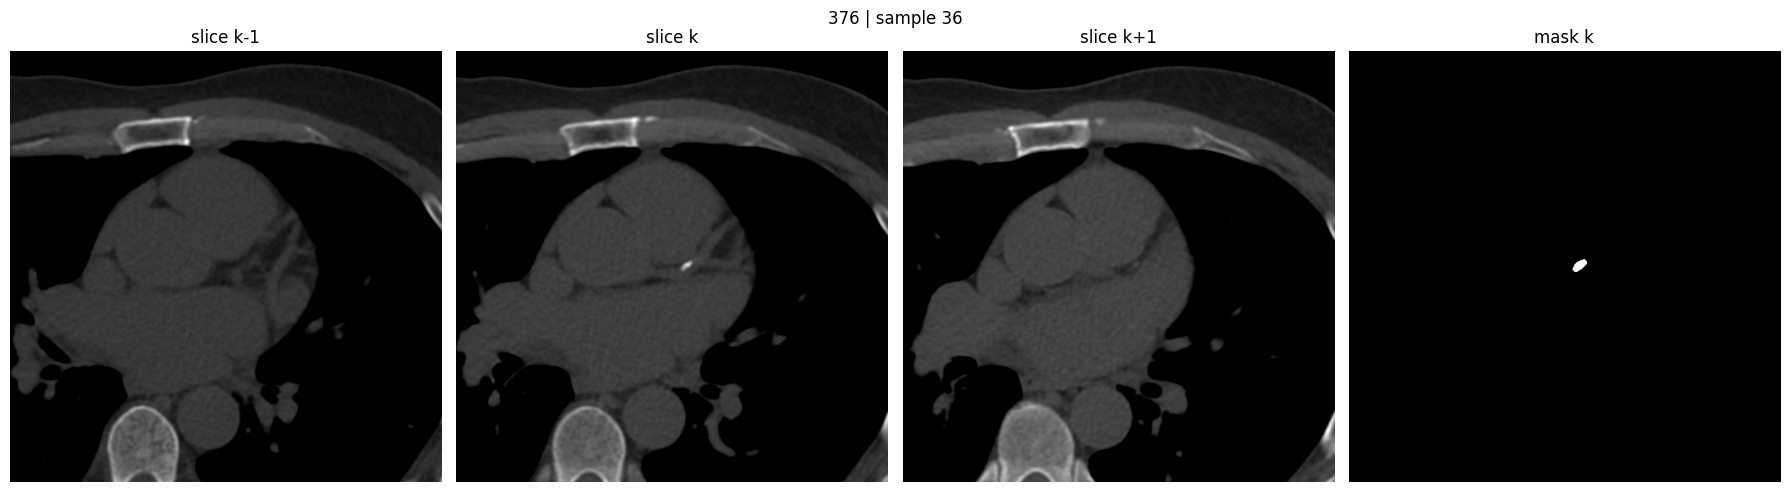

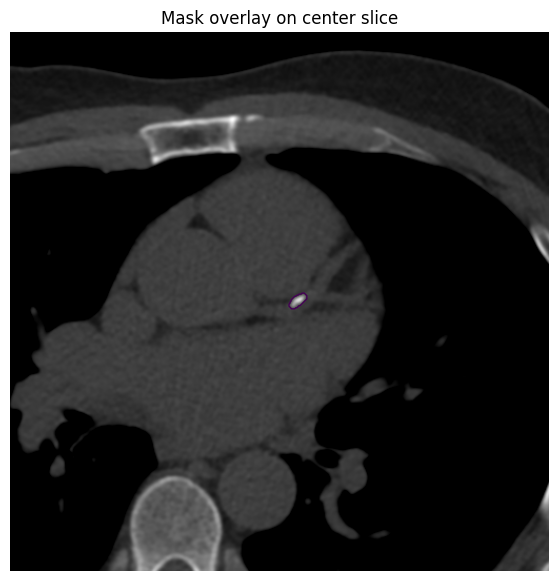

In [49]:
def load_positive_sample(case_id: str):
    row = manifest_df[manifest_df["case_id"] == case_id].iloc[0]
    x = np.load(row["input_path"], mmap_mode="r")
    y = np.load(row["mask_path"], mmap_mode="r")

    positive_idx = np.where(np.sum(y > 0, axis=(1, 2, 3)) > 0)[0]
    # Safe stoppage
    if len(positive_idx) == 0:
        return None
    
    idx = int(positive_idx[0])
    return np.array(x[idx]), np.array(y[idx]), idx

positive_cases = case_stats_df[case_stats_df["positive_samples"] > 0]["case_id"].tolist()
assert positive_cases, "No positive_masks found."

# Loads random case that has positive slices
case_id = random.choice(positive_cases)
x_sample, y_sample, sample_idx = load_positive_sample(case_id)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for i, title in enumerate(["slice k-1", "slice k", "slice k+1"]):
    axes[i].imshow(x_sample[i], cmap="gray")
    axes[i].set_title(title)
    axes[i].axis("off")

axes[3].imshow(y_sample[0], cmap="gray")
axes[3].set_title("mask k")
axes[3].axis("off")
plt.suptitle(f"{case_id} | sample {sample_idx}")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 7))
plt.imshow(x_sample[1], cmap="gray")
if y_sample[0].max() > 0:
    plt.contour(y_sample[0], levels=[0.5], linewidths=1)
plt.title("Mask overlay on center slice")
plt.axis("off")
plt.show()

## Flatten case-level `.npy` arrays into sample-level index
converts from a case-level into a sample-level table (3 slices). Identifying positive slices help for later `oversampling`, computing `pos/neg sample counts`, monitoring `class imbalance`.

In [50]:
def build_sample_index(manifest_subset: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for _, row in manifest_subset.iterrows():
        x = np.load(row["input_path"], mmap_mode="r")
        y = np.load(row["mask_path"], mmap_mode="r")
        # Determine which samples contain CAC
        positive = np.sum(y > 0, axis=(1,2,3)) > 0

        # Storing metadata
        for sample_idx in range(x.shape[0]):
            rows.append({
                "case_id": row["case_id"],
                "split": row["split"],
                "input_path": row["input_path"],
                "mask_path": row["mask_path"],
                "sample_idx": sample_idx,
                "has_cac": int(positive[sample_idx]),
            })

    return pd.DataFrame(rows)

train_index_df = build_sample_index(manifest_df[manifest_df["split"] == "train"])
val_index_df = build_sample_index(manifest_df[manifest_df["split"] == "val"])
test_index_df = build_sample_index(manifest_df[manifest_df["split"] == "test"])

print("Train:", len(train_index_df))
print("Val:", len(val_index_df))
print("Test:", len(test_index_df))
print("\nTrain label ratio:")
print(train_index_df["has_cac"].value_counts(normalize=True))

Train: 16044
Val: 3322
Test: 3626

Train label ratio:
has_cac
0    0.842184
1    0.157816
Name: proportion, dtype: float64


## PyTorch Dataset

In [51]:
class SegmentationDataset(Dataset):
    def __init__(self, index_df: pd.DataFrame):
        self.index_df = index_df.reset_index(drop=True)
        self._input_cache = {}
        self._mask_cache = {}

    def __len__(self):
        return len(self.index_df)

    def _load_case(self, input_path: str, mask_path: str):
        if input_path not in self._input_cache:
            self._input_cache[input_path] = np.load(input_path, mmap_mode="r")
        if mask_path not in self._mask_cache:
            self._mask_cache[mask_path] = np.load(mask_path, mmap_mode="r")
        return self._input_cache[input_path], self._mask_cache[mask_path]

    def __getitem__(self, idx):
        row = self.index_df.iloc[idx]
        x_case, y_case = self._load_case(row["input_path"], row["mask_path"])

        x = np.array(x_case[int(row["sample_idx"])], dtype=np.float32)
        y = np.array(y_case[int(row["sample_idx"])], dtype=np.float32)
        y = (y > 0).astype(np.float32)

        return {
            "image": torch.from_numpy(x),
            "mask": torch.from_numpy(y),
            "case_id": row["case_id"],
            "sample_idx": int(row["sample_idx"]),
            "has_cac": int(row["has_cac"]),
        }

train_ds = SegmentationDataset(train_index_df)
val_ds = SegmentationDataset(val_index_df)
test_ds = SegmentationDataset(test_index_df)

print(len(train_ds), len(val_ds), len(test_ds))


16044 3322 3626


## Weighted sampler for lack of positive masks

Use this for **training only**. Validation/test remain naturally distributed.
Weights mean they will be drawn/called more times than those who are notv weighted.


In [52]:
def make_weighted_sampler(index_df: pd.DataFrame, positive_weight: float = 5.0):
    weights = np.where(index_df["has_cac"].values == 1, positive_weight, 1.0).astype(np.float64)
    return WeightedRandomSampler(
        weights=torch.from_numpy(weights),
        num_samples=len(weights),
        replacement=True,
    )

train_sampler = make_weighted_sampler(train_index_df, positive_weight=5.0)

train_loader = DataLoader(
    train_ds,
    batch_size=cfg.BATCH_SIZE,
    sampler=train_sampler,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=cfg.PIN_MEMORY,
)

val_loader = DataLoader(
    val_ds,
    batch_size=cfg.BATCH_SIZE,
    shuffle=False,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=cfg.PIN_MEMORY,
)

test_loader = DataLoader(
    test_ds,
    batch_size=cfg.BATCH_SIZE,
    shuffle=False,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=cfg.PIN_MEMORY,
)

batch = next(iter(train_loader))
print("Images:", batch["image"].shape)
print("Masks:", batch["mask"].shape)
print("Positive masks in sampled batch:", batch["has_cac"].sum().item())


Images: torch.Size([8, 3, 512, 512])
Masks: torch.Size([8, 1, 512, 512])
Positive masks in sampled batch: 4


## Model section

Replace the placeholder with your real architecture.

Model contract:

```text
        Input : [B, 3, H, W] (B = Batch Size)
                            ↓
Encoder: extract richer features while shrinking resolution
                            ↓
    Bottleneck: deepest, most abstract representation
                            ↓
Decoder: restore resolution while combining encoder details
                            ↓
                        1×1 Conv
                            ↓
        Output logits mask : [B, 1, H, W] logits
```

Do **not** apply sigmoid inside the model. Use logits for `BCEWithLogitsLoss`.


In [ ]:
# Two layers learn richer local patterns: edges, bright dense structures, shape boundaries, lesion-like textures.
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        
        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels, out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            
            nn.Conv2d(
                out_channels, out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )
    
    def forward(self, x):
        return self.block(x)

# Downsampling block : shrinks spatial size, increase semantic richness
class DownBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.MaxPool2d(kernel_size=2, stride=2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.block(x)
    
# Upsampling block
class UpBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()

        self.up = nn.ConvTranspose2d(
            in_channels,
            out_channels,
            kernel_size=2,
            stride=2
        )

        self.conv = DoubleConv(
            out_channels + skip_channels,
            out_channels
        )

    def forward(self, x, skip):
        x = self.up(x)

        # In case of minor shape mismatch due to odd dimensions
        if x.shape[-2:] != skip.shape[-2:]:
            x = nn.functional.interpolate(
                x,
                size=skip.shape[-2:],
                mode="bilinear",
                align_corners=False
            )

        # skip: high-resolution details from encoder
        # x: upsampled decoder features
        x = torch.cat([skip, x], dim=1)
        x = self.conv(x)
        return x
    
class ResidualDilatedBlock(nn.Module):
    """
    - Preserve optimization stability through residual skip path.
    - Enlarge receptive field at bottleneck without extra pooling.
    """
    def __init__(self, in_channels, out_channels, dilations=(1, 2, 4), dropout=0.0):
        super().__init__()
        d1, d2, d3 = dilations
        
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=d1, dilation=d1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=d2, dilation=d2, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.conv3 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=d3, dilation=d3, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels)
        
        self.relu = nn.ReLU(inplace=True)
        
        self.dropout = (
            nn.Dropout2d(dropout)
            if dropout > 0 else nn.Identity()
        )

        # Residual projection if channel count changes
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_channels),
            )
        else: self.shortcut = nn.Identity()
    
    def forward(self, x):
        identity = self.shortcut(x)

        out = self.relu(self.bn1(self.conv1(x)))
        out = self.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))

        out = self.dropout(out)
        
        out = out + identity
        out = self.relu(out)

        return out

class Bottleneck(nn.Module):
    """
    Replace DoubleConv with a residual dilated block
    """
    def __init__(self, in_channels, out_channels, dilations=(1, 2, 4), dropout=0.0):
        super().__init__()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.block = ResidualDilatedBlock(in_channels, out_channels, dilations, dropout,)
    
    def forward(self, x):
        x = self.pool(x)
        x = self.block(x)
        return x
    
# 2.5D U-Net
class UNetModel(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, base_channels=32, dilations=(1, 2, 4), dropout=0.0):
        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(in_channels, base_channels)              # 32
        self.enc2 = DownBlock(base_channels, base_channels * 2)         # 64
        self.enc3 = DownBlock(base_channels * 2, base_channels * 4)     # 128
        self.enc4 = DownBlock(base_channels * 4, base_channels * 8)     # 256

        # Bottleneck
        self.bottleneck = Bottleneck(
            in_channels=base_channels * 8,
            out_channels=base_channels * 16,
            dilations=dilations, dropout=dropout                        # 512
        )

        # Decoder: rebuild full image resolution
        self.up4 = UpBlock(
            in_channels=base_channels * 16,
            skip_channels=base_channels * 8,
            out_channels=base_channels * 8
        )

        self.up3 = UpBlock(
            in_channels=base_channels * 8,
            skip_channels=base_channels * 4,
            out_channels=base_channels * 4
        )

        self.up2 = UpBlock(
            in_channels=base_channels * 4,
            skip_channels=base_channels * 2,
            out_channels=base_channels * 2
        )

        self.up1 = UpBlock(
            in_channels=base_channels * 2,
            skip_channels=base_channels,
            out_channels=base_channels
        )

        # Final segmentation head
        self.out_conv = nn.Conv2d(
            base_channels,
            out_channels,
            kernel_size=1
        )

    def forward(self, x):
        # Encoder
        s1 = self.enc1(x)       # [B, 16, H, W]
        s2 = self.enc2(s1)      # [B, 32, H/2, W/2]
        s3 = self.enc3(s2)      # [B, 64, H/4, W/4]
        s4 = self.enc4(s3)      # [B, 128, H/8, W/8]

        # Bottleneck
        b = self.bottleneck(s4) # [B, 256, H/16, W/16]

        # Decoder
        d4 = self.up4(b, s4)
        d3 = self.up3(d4, s3)
        d2 = self.up2(d3, s2)
        d1 = self.up1(d2, s1)

        # Output logits
        logits = self.out_conv(d1)
        return logits
    
model = UNetModel(
    in_channels=3, out_channels=1,
    base_channels=32,
    dilations=(1, 2, 4), dropout=0.0,
).to(DEVICE)

if USE_CHANNELS_LAST:
    model = model.to(memory_format=torch.channels_last)

batch = next(iter(train_loader))
x = batch["image"].to(DEVICE)

model.eval()
with torch.no_grad():
    logits = model(x) # raw unbounded scores, passed to sigmoid for probabilities

print("Input shape:", x.shape)
print("Output shape:", logits.shape)

Input shape: torch.Size([8, 3, 512, 512])
Output shape: torch.Size([8, 1, 512, 512])


## Loss functions

* Baseline: **Dice + BCEWithLogitsLoss**.
* Optimizeer: AdamW. Handling weight decay more cleanly.
* LR Scheduler: ReduceLROnPlateau.
* AMP uses `autocast` for the forward/loss computation and `GradScaler` to keep FP16 gradients numerically stable.

The segmentation head outputs logits. Sigmoid is applied during loss commputation and threshold-based inference, consistent with BCEWithLogitsLoss

$$Dice = \frac{2 \times |Prediction \cap Target|}{|Prediction| + |Target|}$$

`BCEWithLogitsLoss`: for each pixel, should this be background `0` or CAC `1`.
Internally, it becomes $$sigmoid(logits) + \text{binary cross entropy}$$

| Dice loss helps with: | BCE helps with: |
|---|---|
| overlap quality | stable px-level optimization |
| small lesion segmentation | suppressing fp |
| class imbalance | more informative gradients early in training |

In [90]:
# Overlap with true CAC mask
# Dice = 
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        # Convert logits to probabilities
        probs = torch.sigmoid(logits)
        targets = targets.float()
        dims = (1, 2, 3)

        intersection = torch.sum(probs * targets, dims)
        denominator = torch.sum(probs, dims) + torch.sum(targets, dims)
        dice = (2 * intersection + self.smooth) / (denominator + self.smooth)
        # DiceLoss = 1 - Dice
        return 1 - dice.mean()

# Combine overlap learning + pixel classification
# Actual training loss
class DiceBCELoss(nn.Module):
    def __init__(self, dice_weight=0.5, bce_weight=0.5):
        super().__init__()
        self.dice = DiceLoss()
        # BCEWithLogitsLoss: for each pixel, should this be bg (0) or CAC (1)
        self.bce = nn.BCEWithLogitsLoss()
        self.dice_weight = dice_weight
        self.bce_weight = bce_weight

    def forward(self, logits, targets):
        return self.dice_weight * self.dice(logits, targets) + self.bce_weight * self.bce(logits, targets)

criterion = DiceBCELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)

# Monitor the appropriacy of Learning Rate
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=2, threshold=1e-4, min_lr=1e-6,
)
# Using AMP 
scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

## Resume checkpoint
Continue on what the model has been trained on

In [ ]:
def load_checkpoint(path, model, optimizer=None, scheduler=None, scaler=None, device="cuda"):
    checkpoint = torch.load(path, map_location=device)

    model.load_state_dict(checkpoint["model_state_dict"])

    if optimizer is not None and checkpoint.get("optimizer_state_dict") is not None:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    if scheduler is not None and checkpoint.get("scheduler_state_dict") is not None:
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])

    if scaler is not None and checkpoint.get("scaler_state_dict") is not None:
        scaler.load_state_dict(checkpoint["scaler_state_dict"])

    start_epoch = checkpoint["epoch"] + 1
    history = checkpoint.get("history", [])
    best_score = checkpoint.get("best_score", -1.0)

    print(f"Resumed from epoch {checkpoint['epoch']}")
    print(f"Next epoch: {start_epoch}")
    print(f"Best val positive-slice Dice: {best_score:.4f}")

    return start_epoch, history, best_score

In [ ]:
if LATEST_CKPT_PATH.exists():
    start_epoch, history, best_score = load_checkpoint(
        LATEST_CKPT_PATH, model, optimizer, scheduler, scaler, device=DEVICE,
    )
else:
    start_epoch = 1
    history = []
    best_score = -1.0

Resumed from epoch 20
Next epoch: 21
Best val positive-slice Dice: 1.8860


## Segmentation metrics

Implemented:
- Dice
- IoU
- Precision
- Recall
- lesion-level sensitivity

Add later:
- HD95
- Focal Tversky Loss

In [57]:
def compute_metrics(logits, targets, threshold=0.5, eps=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs >= threshold).float()
    targets = targets.float()

    dims = (1, 2, 3)
    tp = torch.sum(preds * targets, dims)
    fp = torch.sum(preds * (1 - targets), dims)
    fn = torch.sum((1 - preds) * targets, dims)

    dice = (2 * tp + eps) / (2 * tp + fp + fn + eps)
    iou = (tp + eps) / (tp + fp + fn + eps)
    precision = torch.where(
        (tp + fp) > 0,
        tp / (tp + fp + eps),
        torch.zeros_like(tp)
    )
    
    recall = torch.where(
        (tp + fn) > 0,
        tp / (tp + fn + eps),
        torch.zeros_like(tp)
    )

    return {
        "dice": dice.mean().item(),
        "iou": iou.mean().item(),
        "precision": precision.mean().item(),
        "recall": recall.mean().item(),
    }

### Lesion sensitivity metrics
Compute how many ROIs are actually detected.

In [58]:
def compute_lesion_metrics_for_slice(pred_mask, gt_mask):
    """
    pred_mask, gt_mask: 2D numpy arrays with values 0/1
    Returns lesion-level counts for one slice.
    """
    pred_mask = pred_mask.astype(np.uint8)
    gt_mask = gt_mask.astype(np.uint8)

    # 8-connected neighborhoods
    structure = np.ones((3, 3), dtype=np.uint8)

    gt_labeled, n_gt = label(gt_mask, structure=structure)
    pred_labeled, n_pred = label(pred_mask, structure=structure)

    detected_gt_lesions = 0
    fp_pred_lesions = 0

    # GT lesion detection
    for gt_id in range(1, n_gt + 1):
        gt_component = gt_labeled == gt_id
        if np.any(pred_mask[gt_component] > 0):
            detected_gt_lesions += 1

    # Predicted lesion fp
    for pred_id in range(1, n_pred + 1):
        pred_component = pred_labeled == pred_id
        if not np.any(gt_mask[pred_component] > 0):
            fp_pred_lesions += 1
    
    return {
        "gt_lesions": n_gt,
        "pred_lesions": n_pred,
        "detected_gt_lesions": detected_gt_lesions,
        "fp_pred_lesions": fp_pred_lesions,
    }

## Checkpoint saving function

In [ ]:
def save_checkpoint(path, epoch, model, optimizer, scheduler, scaler, history, best_score):
    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict() if scheduler is not None else None,
            "scaler_state_dict": scaler.state_dict() if scaler is not None else None,
            "history": history,
            "best_score": best_score,
        },
        path
    )

## Train/validation loop skeleton

### Lesion metrics
This is a 2D slice-level lesion analysis.

In [100]:
def train_one_epoch(model, loader, optimizer, criterion, device, scaler):
    model.train()
    running_loss = 0.0
    metrics_store = {"dice": [], "iou": [], "precision": [], "recall": []}

    pbar = tqdm(loader, desc="Training", leave=False)

    for batch in pbar:
        x = batch["image"].to(device, non_blocking=True)
        y = batch["mask"].to(device, non_blocking=True)

        if USE_CHANNELS_LAST:
            x = x.contiguous(memory_format=torch.channels_last)

        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=USE_AMP):
            logits = model(x)
            loss = criterion(logits, y)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item() * x.size(0)

        metrics = compute_metrics(logits.detach(), y, threshold=cfg.MASK_THRESHOLD)

        for k, v in metrics.items():
            metrics_store[k].append(v)

        pbar.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss = running_loss / len(loader.dataset)
    epoch_metrics = {k: float(np.mean(v)) for k, v in metrics_store.items()}
    return epoch_loss, epoch_metrics


@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device, threshold=cfg.MASK_THRESHOLD, eps=1e-6):
    model.eval()
    running_loss = 0.0
    
    # Storing the metrics of full epoch, both neg and pos slices.
    full_metrics = {"dice": [], "iou": [], "precision": [], "recall": []}

    # Storing the metrics of positive slices only
    pos_metrics = {"pos_dice": [], "pos_precision": [], "pos_recall": []}

    # Negative slice false positives
    neg_false_metrics = {"neg_fp_pixels": [], "neg_pred_positive_samples": 0, "neg_total_samples": 0}

    # Global metrics
    global_px_counts = {
        "tp": 0.0,
        "fp": 0.0,
        "fn": 0.0,
    }

    # Lesions debugging
    lesion_counts = {
        "gt_lesions": 0,
        "pred_lesions": 0,
        "detected_gt_lesions": 0,
        "fp_pred_lesions": 0,
    }

    pbar = tqdm(loader, desc="Validation", leave=False)

    for batch in pbar:
        x = batch["image"].to(device, non_blocking=True)
        y = batch["mask"].to(device, non_blocking=True)

        if USE_CHANNELS_LAST:
            x = x.contiguous(memory_format=torch.channels_last)
        
        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=USE_AMP
        ):
            logits = model(x)
            loss = criterion(logits, y)

        running_loss += loss.item() * x.size(0)

        probs = torch.sigmoid(logits)
        preds = (probs >= threshold).float()

        for i in range(y.size(0)):
            gt = y[i]
            pred = preds[i]

            tp = (pred * gt).sum()
            fp = (pred * (1 - gt)).sum()
            fn = ((1 - pred) * gt).sum()

            # ------------------
            # Global metrics
            # ------------------
            global_px_counts["tp"] += tp.item()
            global_px_counts["fp"] += fp.item()
            global_px_counts["fn"] += fn.item()

            # ------------------
            # All-slice metrics
            # ------------------
            dice = (2 * tp + eps) / (2 * tp + fp + fn + eps)
            iou = (tp + eps) / (tp + fp + fn + eps)

            if (tp + fp) > 0:
                precision = tp / (tp + fp + eps)
            else:
                precision = torch.tensor(0.0, device=device)
            
            if (tp + fn) > 0:
                recall = tp / (tp + fn + eps)
            else:
                recall = torch.tensor(0.0, device=device)
            
            full_metrics["dice"].append(dice.item())
            full_metrics["iou"].append(iou.item())
            full_metrics["precision"].append(precision.item())
            full_metrics["recall"].append(recall.item())

            # ------------------
            # Pos / Neg split
            # ------------------
            gt_has_cac = gt.sum() > 0

            if gt_has_cac:
                pos_metrics["pos_dice"].append(dice.item())
                pos_metrics["pos_precision"].append(precision.item())
                pos_metrics["pos_recall"].append(recall.item())
            else:
                neg_false_metrics["neg_total_samples"] += 1
                neg_false_metrics["neg_fp_pixels"].append(fp.item())
                if pred.sum() > 0:
                    neg_false_metrics["neg_pred_positive_samples"] += 1

            # ------------------
            # Lesion evaluation
            # ------------------
            lesion_res = compute_lesion_metrics_for_slice(
                pred.squeeze().detach().cpu().numpy(),
                gt.squeeze().detach().cpu().numpy(),
            )

            for k in lesion_counts:
                lesion_counts[k] += lesion_res[k]
                
        pbar.set_postfix(loss=f"{loss.item():4f}")

    # Global metrics
    global_px_precision = (
        global_px_counts["tp"] /
        (global_px_counts["tp"] + global_px_counts["fp"] + eps)
    )

    global_px_recall = (
        global_px_counts["tp"] /
        (global_px_counts["tp"] + global_px_counts["fn"] + eps)
    )
    
    # Typical metrics
    all_metrics = {
            "dice": float(np.mean(full_metrics["dice"])),
            "iou": float(np.mean(full_metrics["iou"])),
            "precision": float(np.mean(full_metrics["precision"])),
            "recall": float(np.mean(full_metrics["recall"])),

            "global_precision": float(global_px_precision),
            "global_recall": float(global_px_recall),
        }

    # Pos / Neg split metrics
    separated_metrics = {
        "positive_slice_dice": float(np.mean(pos_metrics["pos_dice"])) if pos_metrics["pos_dice"] else None,
        "positive_slice_precision": float(np.mean(pos_metrics["pos_precision"])) if pos_metrics["pos_precision"] else None,
        "positive_slice_recall": float(np.mean(pos_metrics["pos_recall"])) if pos_metrics["pos_recall"] else None,

        "negative_slice_mean_fp_pixels": (
            float(np.mean(neg_false_metrics["neg_fp_pixels"])) if neg_false_metrics["neg_fp_pixels"] else None
        ),

        "negative_slice_fp_sample_rate": (
            neg_false_metrics["neg_pred_positive_samples"] / neg_false_metrics["neg_total_samples"]
            if neg_false_metrics["neg_total_samples"] > 0 else None
        ),

        "num_positive_slices": len(pos_metrics["pos_dice"]),
        "num_negative_slices": neg_false_metrics["neg_total_samples"],
    }

    # Lesion metrics
    lesion_sensitivity = (
        lesion_counts["detected_gt_lesions"] /
        (lesion_counts["gt_lesions"] + eps)
    )
    lesion_precision = (
        (lesion_counts["pred_lesions"] - lesion_counts["fp_pred_lesions"]) /
        (lesion_counts["pred_lesions"] + eps)
    )
    fp_lesions_per_slice = (
        lesion_counts["fp_pred_lesions"] / len(loader.dataset)
    )
    lesion_metrics = {
        "sensitivity": float(lesion_sensitivity), "precision": float(lesion_precision),
        "fp_per_slice": float(fp_lesions_per_slice),
        "gt_total": int(lesion_counts["gt_lesions"]),
        "pred_total": int(lesion_counts["pred_lesions"]),
        "fp_lesions_total": int(lesion_counts["fp_pred_lesions"]),
    }

    val_loss = running_loss / len(loader.dataset)
    return val_loss, all_metrics, separated_metrics, lesion_metrics

## Sanity time taken

In [61]:
# # RUN THIS ONLY FOR TIMING DEBUGGING
# import time

# model.train()
# start = time.time()

# num_test_batches = 20

# for batch_idx, batch in enumerate(train_loader):
#     if batch_idx >= num_test_batches:
#         break

#     x = batch["image"].to(DEVICE, non_blocking=True)
#     y = batch["mask"].to(DEVICE, non_blocking=True)

#     optimizer.zero_grad(set_to_none=True)
#     logits = model(x)
#     loss = criterion(logits, y)
#     loss.backward()
#     optimizer.step()

# elapsed = time.time() - start
# sec_per_batch = elapsed / num_test_batches

# print(f"Seconds per training batch: {sec_per_batch:.3f}")
# print(f"Estimated training-only epoch time: {sec_per_batch * len(train_loader) / 60:.1f} minutes")

## Train + Validate

In [ ]:
best_model_path = BEST_WEIGHTS_PATH

for epoch in range(start_epoch, cfg.EPOCHS + 1):
    start = time.time()

    train_loss, train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE, scaler)
    val_loss, val_metrics, val_sep_metrics, lesion_metrics = validate_one_epoch(model, val_loader, criterion, DEVICE)
    scheduler_metric = val_sep_metrics["positive_slice_dice"]

    if scheduler_metric is not None:
        scheduler.step(scheduler_metric)
    elapsed = time.time() - start

    current_lr = optimizer.param_groups[0]["lr"]

    row = {
        "epoch": epoch,
        "lr": current_lr,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_dice": train_metrics["dice"],
        "val_dice": val_metrics["dice"],
        "train_iou": train_metrics["iou"],
        "val_iou": val_metrics["iou"],
        "train_precision": train_metrics["precision"],
        "val_precision_all": val_metrics["precision"],
        "train_recall": train_metrics["recall"],
        "val_recall_all": val_metrics["recall"],

        "val_pos_dice": val_sep_metrics["positive_slice_dice"],
        "val_pos_precision": val_sep_metrics["positive_slice_precision"],
        "val_pos_recall": val_sep_metrics["positive_slice_recall"],
        "val_neg_fp_rate": val_sep_metrics["negative_slice_fp_sample_rate"],
        "val_neg_mean_fp_pixels": val_sep_metrics["negative_slice_mean_fp_pixels"],

        "lesion_sensitivity": lesion_metrics["sensitivity"],
        "lesion_precision": lesion_metrics["precision"],
        "lesion_fp": lesion_metrics["fp_per_slice"],
        "seconds": elapsed,
    }
    history.append(row)

    # Go for the validation for slices that have CAC
    best_val = val_sep_metrics["positive_slice_dice"] * 0.6 + lesion_metrics["precision"] * 0.2 + val_metrics["global_precision"] * 0.2

    if best_val is not None and best_val > best_score:
        best_score = best_val
        torch.save(model.state_dict(), best_model_path)

        # Full checkpoint
        save_checkpoint(BEST_CKPT_PATH, epoch, model, optimizer, scheduler, scaler, history, best_score)

    print(
        f"Epoch {epoch:02d}/{cfg.EPOCHS} | "
        f"lr={current_lr:.2e} | "
        f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
        f"train_dice={train_metrics['dice']:.4f} | val_dice={val_metrics['dice']:.4f} | "
        f"val_precision={val_metrics['precision']:.4f} | val_recall={val_metrics['recall']:.4f} | "
        f"pos_dice={fmt(val_sep_metrics['positive_slice_dice'])} | "
        f"pos_recall={fmt(val_sep_metrics['positive_slice_recall'])} | "
        f"neg_fp_rate={fmt(val_sep_metrics['negative_slice_fp_sample_rate'])} | "
        f"Global pixel Precision={val_metrics["global_precision"]:.4f} | Recall={val_metrics["global_recall"]:.4f} | "
        f"{elapsed:.1f}s"
    )

    save_checkpoint(LATEST_CKPT_PATH, epoch, model, optimizer, scheduler, scaler, history, best_score)

history_df = pd.DataFrame(history)
history_df.tail()

Training:   0%|          | 0/2006 [00:00<?, ?it/s]

After two epochs, the model achieved high sensitivity for calcium detection, recovering 84.2% of true CAC pixels globally and detecting 89.8% of annotated CAC lesions. However, the model substantially over-segmented calcium-like regions, with a global pixel precision of 27.2%, lesion-level precision of 31.9%, and fp predictions in 27.1% of CAC-negative slices. These results indicate that the model is learning CAC localization but requires further training and false positive suppresion.

After 10 epochs, 
| Metrics scoring | ye |
| --- | --- |
| pos_dice = 0.9235 | pos_recall = 0.9165 |
| global precision = 0.8403 | global recall = 0.9380 |
| neg_fp_rate = 0.0593 | |

This means on slices that truly contain CAC, the predicted masks overlap the annotations extremely well. The model is still highly sensity, but no longer recklessly overpredicting.

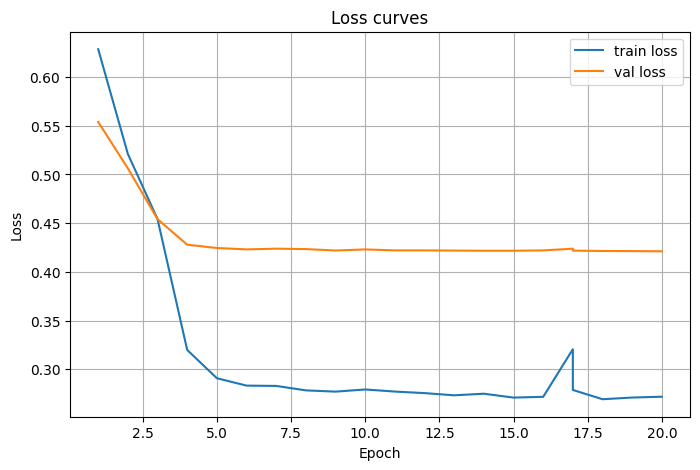

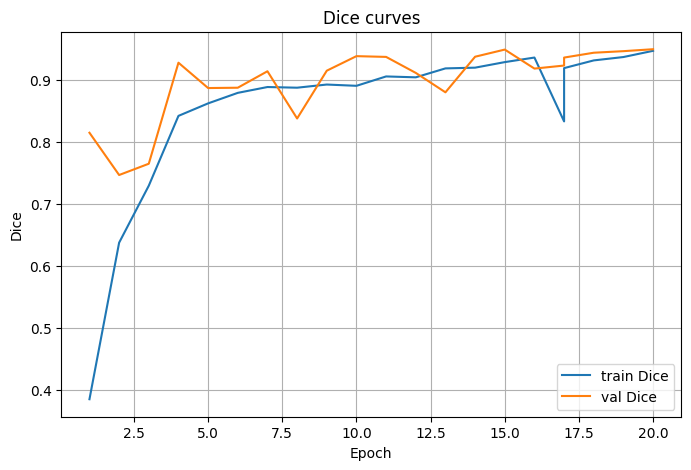

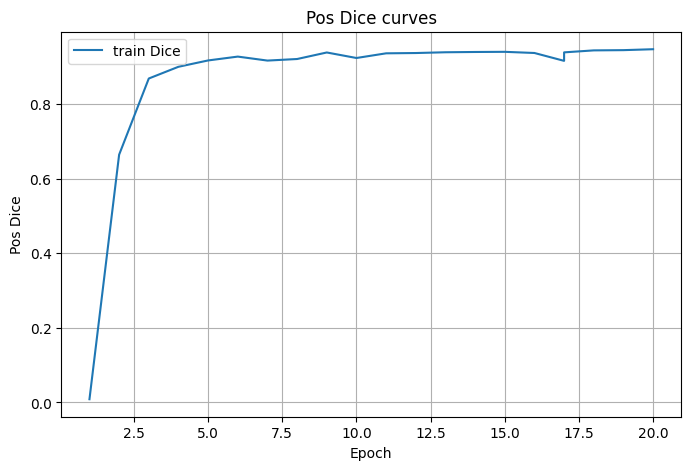

In [107]:
if len(history_df) > 0:
    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_loss"], label="train loss")
    plt.plot(history_df["epoch"], history_df["val_loss"], label="val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss curves")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_dice"], label="train Dice")
    plt.plot(history_df["epoch"], history_df["val_dice"], label="val Dice")
    plt.xlabel("Epoch")
    plt.ylabel("Dice")
    plt.title("Dice curves")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["val_pos_dice"], label="train Dice")
    plt.xlabel("Epoch")
    plt.ylabel("Pos Dice")
    plt.title("Pos Dice curves")
    plt.legend()
    plt.grid(True)
    plt.show()

## Test evaluation

Only run this after architecture decisions are finalized.


In [108]:
if BEST_CKPT_PATH.exists():
    best_checkpoint = torch.load(BEST_CKPT_PATH, map_location=DEVICE)
    model.load_state_dict(best_checkpoint["model_state_dict"])

    test_loss, test_metrics, test_sep_metrics, test_lesion_metrics = validate_one_epoch(
        model,
        test_loader,
        criterion,
        DEVICE
    )

    print("Loaded best checkpoint from epoch:", best_checkpoint["epoch"])
    print("Test loss:", round(test_loss, 4))

    print("Test metrics:")
    for k, v in test_metrics.items():
        print(f"{k}: {v:.4f}")

    print("Test positive/negative-separated metrics:")
    for k, v in test_sep_metrics.items():
        print(f"{k}: {v}")

    print("Test lesion-level metrics:")
    for k, v in test_lesion_metrics.items():
        print(f"{k}: {v}")

else:
    print("No best checkpoint found.")

Validation:   0%|          | 0/454 [00:00<?, ?it/s]

Loaded best checkpoint from epoch: 20
Test loss: 0.4339
Test metrics:
dice: 0.8966
iou: 0.8917
precision: 0.1350
recall: 0.1340
global_precision: 0.6407
global_recall: 0.8142
Test positive/negative-separated metrics:
positive_slice_dice: 0.8458130083171983
positive_slice_precision: 0.8574567521072519
positive_slice_recall: 0.8506798974373713
negative_slice_mean_fp_pixels: 10.585924713584289
negative_slice_fp_sample_rate: 0.0939443535188216
num_positive_slices: 571
num_negative_slices: 3055
Test lesion-level metrics:
sensitivity: 0.8785425092322444
precision: 0.5978186771657678
fp_per_slice: 0.16271373414230558
gt_total: 988
pred_total: 1467
fp_lesions_total: 590


## Qualitative prediction display

Inspect false positives and false negatives. A metric without visual review is not enough in medical segmentation.

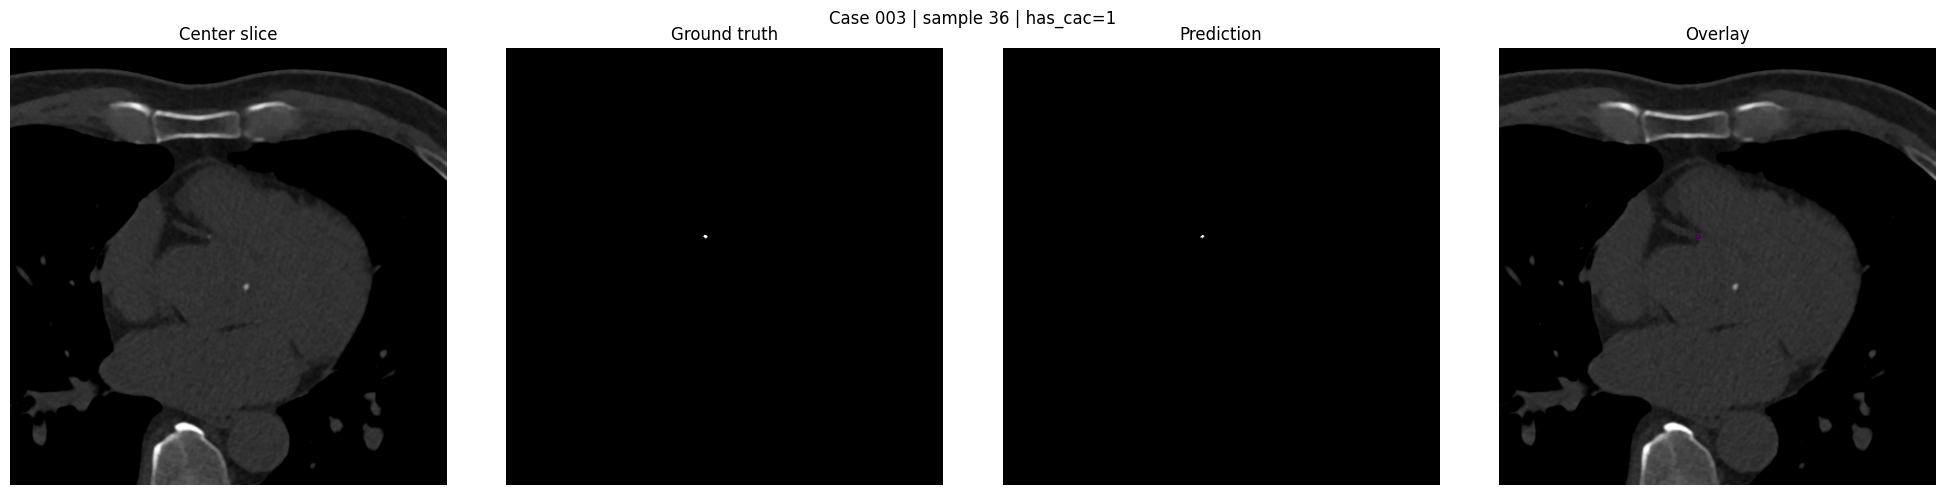

In [85]:
@torch.no_grad()
def visualize_prediction(model, dataset, idx=0, threshold=0.5):
    model.eval()
    item = dataset[idx]

    x = item["image"].unsqueeze(0).to(DEVICE)
    gt = item["mask"][0].cpu().numpy()

    logits = model(x)
    prob = torch.sigmoid(logits)[0, 0].cpu().numpy()
    pred = (prob >= threshold).astype(np.float32)

    center = item["image"][1].cpu().numpy()

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    axes[0].imshow(center, cmap="gray")
    axes[0].set_title("Center slice")
    axes[0].axis("off")

    axes[1].imshow(gt, cmap="gray")
    axes[1].set_title("Ground truth")
    axes[1].axis("off")

    axes[2].imshow(pred, cmap="gray")
    axes[2].set_title("Prediction")
    axes[2].axis("off")

    axes[3].imshow(center, cmap="gray")
    if gt.max() > 0:
        axes[3].contour(gt, levels=[0.5], linewidths=1)
    if pred.max() > 0:
        axes[3].contour(pred, levels=[0.5], linewidths=1)
    axes[3].set_title("Overlay")
    axes[3].axis("off")

    plt.suptitle(f"Case {item['case_id']} | sample {item['sample_idx']} | has_cac={item['has_cac']}")
    plt.tight_layout()
    plt.show()

# Run after training:
visualize_prediction(model, test_ds, idx=36, threshold=cfg.MASK_THRESHOLD)


# Summary

Creating a baseline U-Net
Later add more techniques like Residual + dilated bottleneck variant, HD95 metric, Lesion-level sensitivity

Residual blocks can make deeper transformations easier to optimize by preserving an identity path through the block.
`Dilated conv` enlarge receptve field without further downsampling resolution. Broader context could help distinguish true coronary calcium vs bright nearby non-coronary structures